# Dataset Analysis by Center


In [2]:
import sys
from pathlib import Path
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn'])


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

ROOT = Path('..').resolve()

df_old = pd.read_csv(ROOT / 'data/dataframe_cleaned_old.csv', sep=';')
df_center = pd.read_csv(ROOT / 'data/dataframe_cleaned_2_with_center.csv', sep=';')[['Order', 'Center']]
df = df_old.merge(df_center, on='Order', how='left')
df.columns = df.columns.str.strip()

# Centers sorted by size (descending)
CENTER_ORDER = df['Center'].value_counts().index.tolist()

# Feature lists
ALL_FEATURES = [c for c in df.columns if c not in ['Order', 'outcome', 'Center']]

SHAP_ORDER = [
    'pirads', 'psa_density', 'age', 'prostate_volume', 'ant',
    'clinical_stage', 'diameter', 'contralateral_suspicious', 'contralateral_diameter',
    'suspicious_trus', 'psa', 'prev_neg_trus_biopsy', 'post', 'median', 'base',
    'family_history', 'epe', 'nb_susp_lesions', 'apical', 'contralateral_pirads', 'mid'
]

BINARY_FEATURES = [
    'suspicious_trus', 'family_history', 'prev_neg_trus_biopsy', 'clinical_stage',
    'contralateral_suspicious', 'epe', 'ant', 'mid', 'post', 'base', 'median', 'apical'
]
CONTINUOUS_FEATURES = [
    'age', 'psa', 'prostate_volume', 'nb_susp_lesions', 'pirads',
    'diameter', 'contralateral_pirads', 'contralateral_diameter', 'psa_density'
]

print(f'Dataset: {df.shape[0]} patients, {len(ALL_FEATURES)} features, {df["Center"].nunique()} centers')
print(df['Center'].value_counts().to_string())

Dataset: 4841 patients, 21 features, 15 centers
Center
DE (Berlin)          1097
BE (Bordet)           652
IT (Turin)            463
IT (Regina)           448
Brest                 369
FR (Reims)            340
CZ (Ostrava)          267
FR (Bordeaux)         261
FR (Grenoble)         233
FR (Toulouse)         201
FR (Cochin)           129
CH (Geneve)           127
PL (Zielona Góra)     100
FR (Pompidou)          82
BE (St Eli)            72


---
## 1. NaN Analysis

### 1.1 NaN % per feature

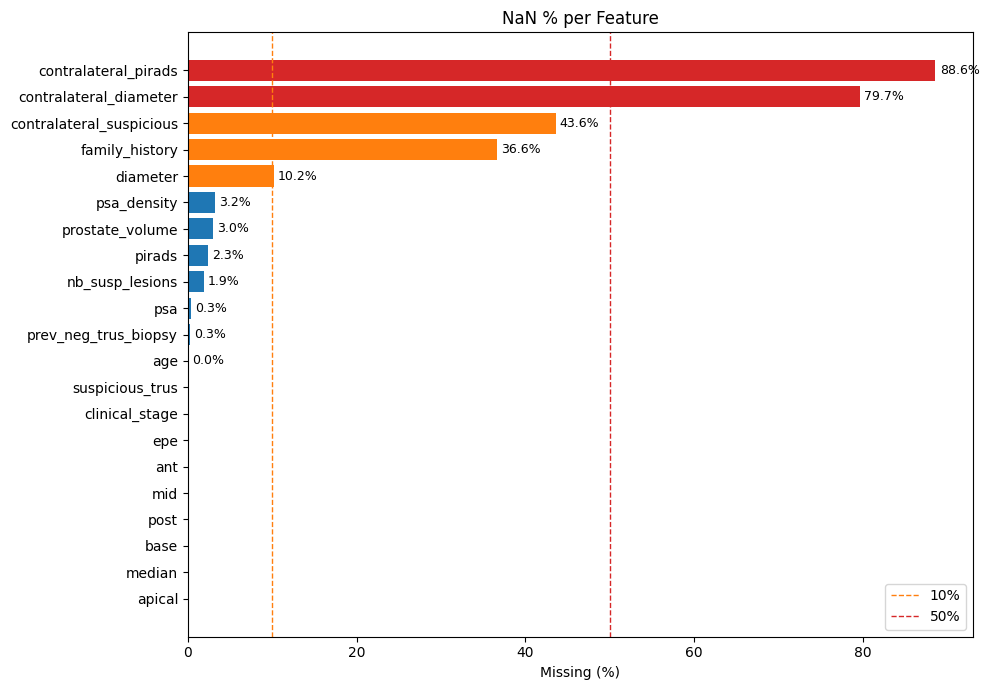

contralateral_pirads        88.638711
contralateral_diameter      79.694278
contralateral_suspicious    43.606693
family_history              36.645321
diameter                    10.204503
psa_density                  3.243132
prostate_volume              2.974592
pirads                       2.334228
nb_susp_lesions              1.900434
psa                          0.330510
prev_neg_trus_biopsy         0.289196
age                          0.020657
suspicious_trus              0.000000
clinical_stage               0.000000
epe                          0.000000
ant                          0.000000
mid                          0.000000
post                         0.000000
base                         0.000000
median                       0.000000
apical                       0.000000


In [3]:
nan_pct = df[ALL_FEATURES].isna().mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if v > 50 else '#ff7f0e' if v > 10 else '#1f77b4' for v in nan_pct]
bars = ax.barh(nan_pct.index[::-1], nan_pct.values[::-1], color=colors[::-1])
ax.axvline(10, color='#ff7f0e', linestyle='--', linewidth=1, label='10%')
ax.axvline(50, color='#d62728', linestyle='--', linewidth=1, label='50%')
for bar, val in zip(bars, nan_pct.values[::-1]):
    if val > 0:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('NaN % per Feature')
ax.legend()
plt.tight_layout()
plt.savefig('fig1_nan_per_feature.png', dpi=150)
plt.show()
print(nan_pct.to_string())

### 1.2 NaN % per patient

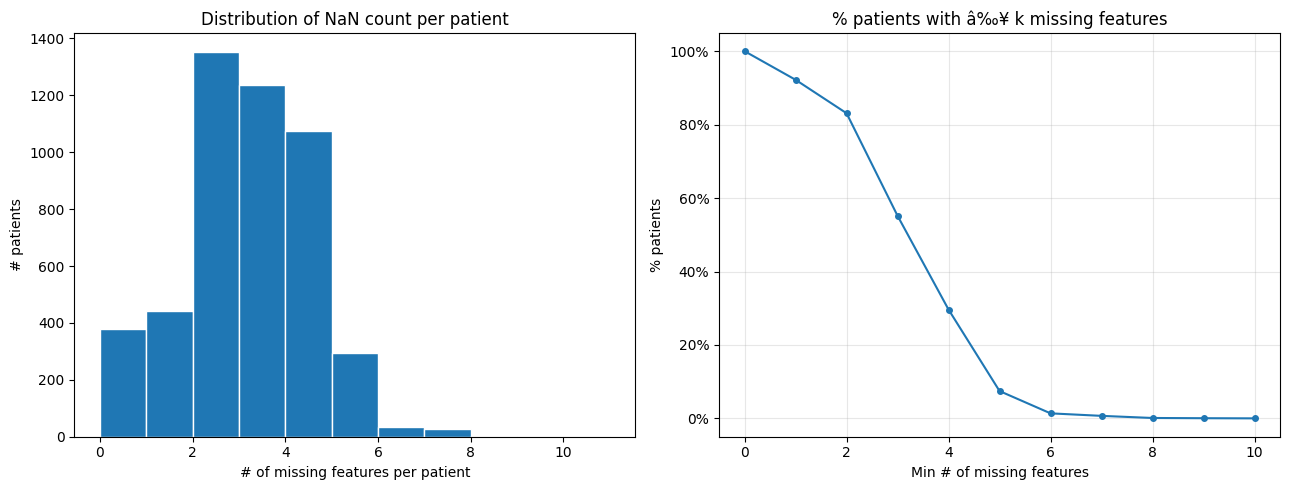

Patients with 0 NaN   : 377 (7.8%)
Patients with â‰¥1 NaN  : 4464 (92.2%)
Patients with â‰¥2 NaN  : 4023 (83.1%)
Patients with â‰¥3 NaN  : 2671 (55.2%)


In [4]:
nan_per_patient = df[ALL_FEATURES].isna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution of NaN count
axes[0].hist(nan_per_patient, bins=range(0, nan_per_patient.max() + 2), edgecolor='white', color='#1f77b4')
axes[0].set_xlabel('# of missing features per patient')
axes[0].set_ylabel('# patients')
axes[0].set_title('Distribution of NaN count per patient')

# Cumulative: % patients with at least k NaN features
thresholds = range(0, nan_per_patient.max() + 1)
pct_with_at_least = [(nan_per_patient >= k).mean() * 100 for k in thresholds]
axes[1].plot(list(thresholds), pct_with_at_least, marker='o', markersize=4)
axes[1].set_xlabel('Min # of missing features')
axes[1].set_ylabel('% patients')
axes[1].set_title('% patients with â‰¥ k missing features')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_nan_per_patient.png', dpi=150)
plt.show()

print(f'Patients with 0 NaN   : {(nan_per_patient == 0).sum()} ({(nan_per_patient == 0).mean()*100:.1f}%)')
print(f'Patients with â‰¥1 NaN  : {(nan_per_patient >= 1).sum()} ({(nan_per_patient >= 1).mean()*100:.1f}%)')
print(f'Patients with â‰¥2 NaN  : {(nan_per_patient >= 2).sum()} ({(nan_per_patient >= 2).mean()*100:.1f}%)')
print(f'Patients with â‰¥3 NaN  : {(nan_per_patient >= 3).sum()} ({(nan_per_patient >= 3).mean()*100:.1f}%)')

### 1.3 Dataset size if we drop patients with any NaN â€” per feature

Patients with COMPLETE data (no NaN in any feature): 377 / 4841 (7.8%)

                 feature  nan_count nan_%  remaining_patients remaining_%
    contralateral_pirads       4291 88.6%                 550       11.4%
  contralateral_diameter       3858 79.7%                 983       20.3%
contralateral_suspicious       2111 43.6%                2730       56.4%
          family_history       1774 36.6%                3067       63.4%
                diameter        494 10.2%                4347       89.8%
             psa_density        157  3.2%                4684       96.8%
         prostate_volume        144  3.0%                4697       97.0%
                  pirads        113  2.3%                4728       97.7%
         nb_susp_lesions         92  1.9%                4749       98.1%
                     psa         16  0.3%                4825       99.7%
    prev_neg_trus_biopsy         14  0.3%                4827       99.7%
                     age          1  0.0

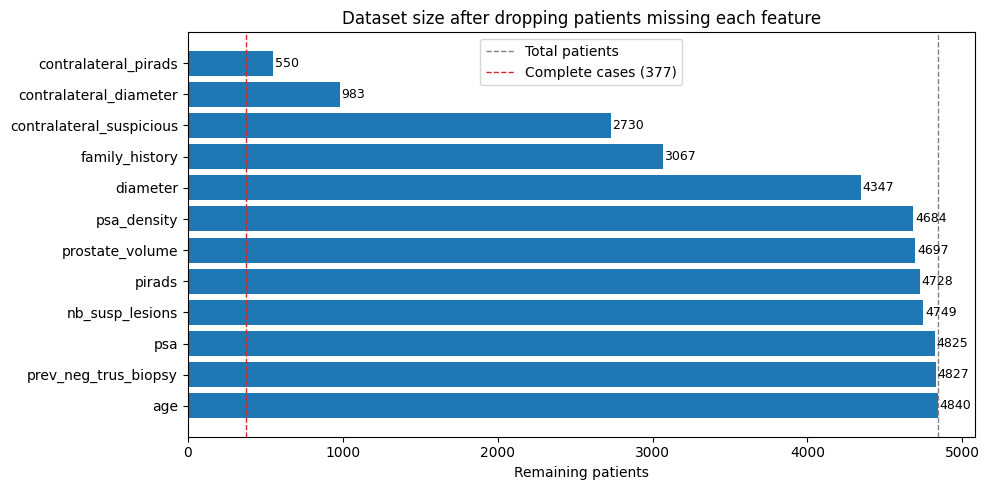

In [5]:
n_total = len(df)
rows = []
for feat in nan_pct[nan_pct > 0].index:
    n_drop = df[feat].isna().sum()
    n_remain = n_total - n_drop
    rows.append({'feature': feat, 'nan_count': n_drop, 'nan_%': f'{n_drop/n_total*100:.1f}%',
                 'remaining_patients': n_remain, 'remaining_%': f'{n_remain/n_total*100:.1f}%'})

# Cost of dropping ALL patients with any NaN
n_complete = df[ALL_FEATURES].dropna().shape[0]
print(f'Patients with COMPLETE data (no NaN in any feature): {n_complete} / {n_total} ({n_complete/n_total*100:.1f}%)')
print()
drop_df = pd.DataFrame(rows).sort_values('nan_count', ascending=False)
print(drop_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
feats = drop_df['feature'].tolist()
remainders = drop_df['remaining_patients'].tolist()
bars = ax.barh(feats[::-1], remainders[::-1], color='#1f77b4')
ax.axvline(n_total, color='gray', linestyle='--', linewidth=1, label='Total patients')
ax.axvline(n_complete, color='#d62728', linestyle='--', linewidth=1, label=f'Complete cases ({n_complete})')
for bar, val in zip(bars, remainders[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Remaining patients')
ax.set_title('Dataset size after dropping patients missing each feature')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_dataset_size_after_drop.png', dpi=150)
plt.show()

---
## 2. Center Overview

### 2.1 Patient count & outcome rate per center

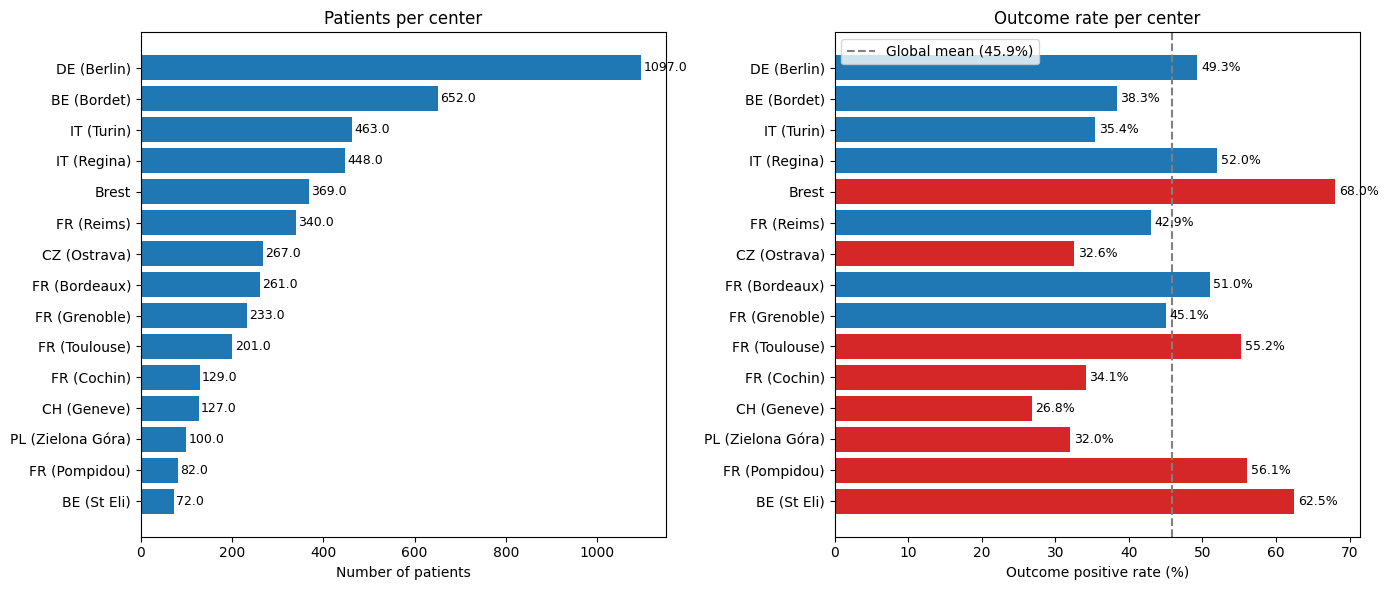

                   n_patients  outcome_rate
Center                                     
DE (Berlin)              1097      0.493163
BE (Bordet)               652      0.383436
IT (Turin)                463      0.354212
IT (Regina)               448      0.520089
Brest                     369      0.680217
FR (Reims)                340      0.429412
CZ (Ostrava)              267      0.325843
FR (Bordeaux)             261      0.509579
FR (Grenoble)             233      0.450644
FR (Toulouse)             201      0.552239
FR (Cochin)               129      0.341085
CH (Geneve)               127      0.267717
PL (Zielona Góra)         100      0.320000
FR (Pompidou)              82      0.560976
BE (St Eli)                72      0.625000


In [6]:
center_stats = df.groupby('Center').agg(
    n_patients=('outcome', 'count'),
    outcome_rate=('outcome', 'mean')
).reindex(CENTER_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(center_stats.index[::-1], center_stats['n_patients'][::-1], color='#1f77b4')
for i, (idx, row) in enumerate(center_stats[::-1].iterrows()):
    axes[0].text(row['n_patients'] + 5, i, str(row['n_patients']), va='center', fontsize=9)
axes[0].set_xlabel('Number of patients')
axes[0].set_title('Patients per center')

colors_rate = ['#d62728' if v > 0.55 or v < 0.35 else '#1f77b4' for v in center_stats['outcome_rate'][::-1]]
axes[1].barh(center_stats.index[::-1], center_stats['outcome_rate'][::-1] * 100, color=colors_rate)
axes[1].axvline(df['outcome'].mean() * 100, color='gray', linestyle='--', linewidth=1.5, label=f'Global mean ({df["outcome"].mean()*100:.1f}%)')
for i, (idx, row) in enumerate(center_stats[::-1].iterrows()):
    axes[1].text(row['outcome_rate'] * 100 + 0.5, i, f"{row['outcome_rate']*100:.1f}%", va='center', fontsize=9)
axes[1].set_xlabel('Outcome positive rate (%)')
axes[1].set_title('Outcome rate per center')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_center_overview.png', dpi=150)
plt.show()
print(center_stats.to_string())

---
## 3. NaN % per feature per center

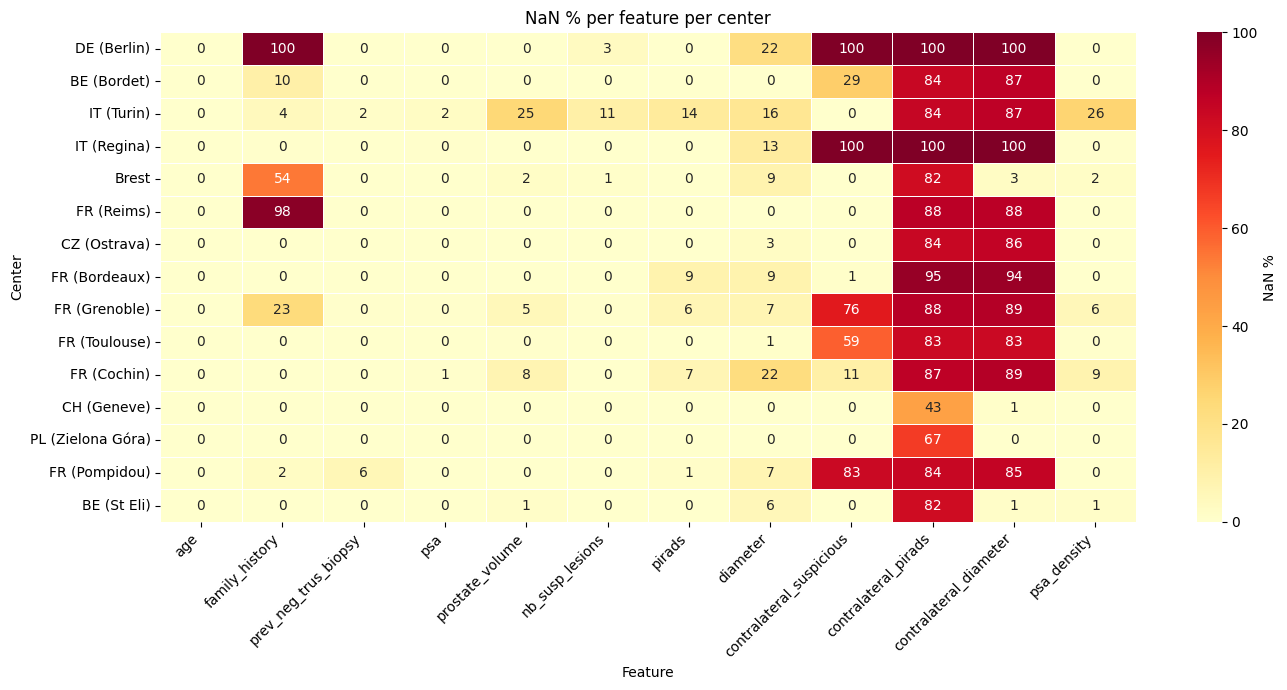

In [7]:
nan_by_center = df.groupby('Center')[ALL_FEATURES].apply(lambda g: g.isna().mean() * 100)
nan_by_center = nan_by_center.reindex(CENTER_ORDER)

# Only show features that have at least some NaN somewhere
cols_with_nan = nan_by_center.columns[nan_by_center.max() > 0]
heatmap_data = nan_by_center[cols_with_nan]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'NaN %'}
)
ax.set_title('NaN % per feature per center')
ax.set_xlabel('Feature')
ax.set_ylabel('Center')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig5_nan_by_center.png', dpi=150)
plt.show()

---
## 4. Feature Distributions by Center (ordered by SHAP importance)
- **Continuous features**: boxplot per center + Kruskal-Wallis test
- **Binary features**: % positive per center + Chi-squared test

In [8]:
def kruskal_pvalue(df, feature, center_col='Center'):
    groups = [g[feature].dropna().values for _, g in df.groupby(center_col)]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2:
        return np.nan
    stat, p = stats.kruskal(*groups)
    return p

def chi2_pvalue(df, feature, center_col='Center'):
    ct = pd.crosstab(df[center_col], df[feature].dropna())
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    return p

def pval_label(p):
    if np.isnan(p): return 'p=N/A'
    if p < 0.001: return 'p<0.001 ***'
    if p < 0.01: return f'p={p:.3f} **'
    if p < 0.05: return f'p={p:.3f} *'
    return f'p={p:.3f}'

print('Helper functions defined.')

Helper functions defined.


C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


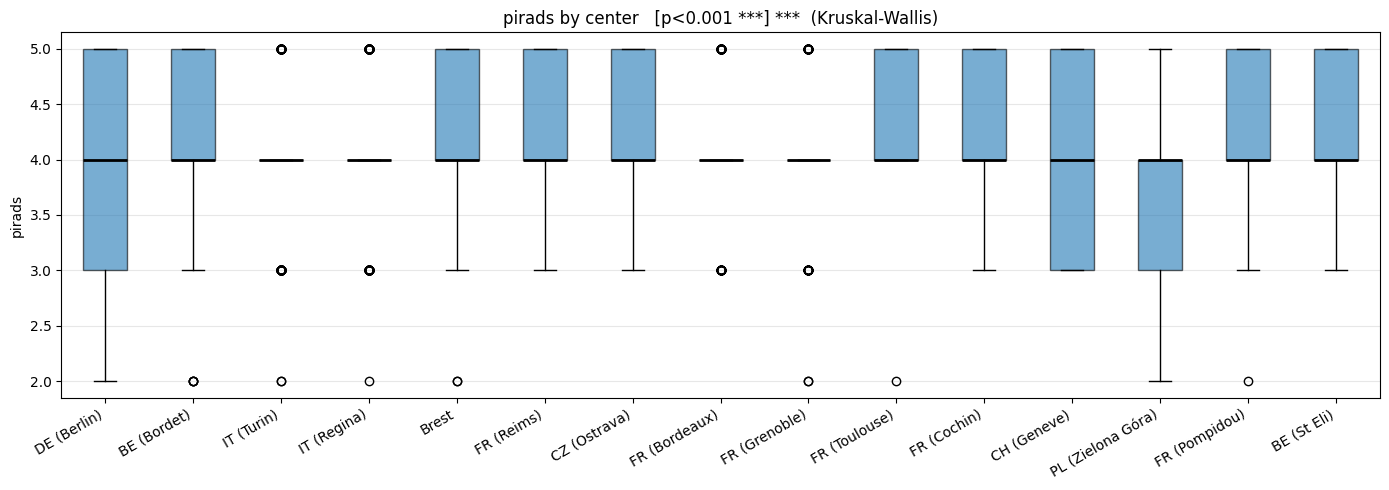

C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


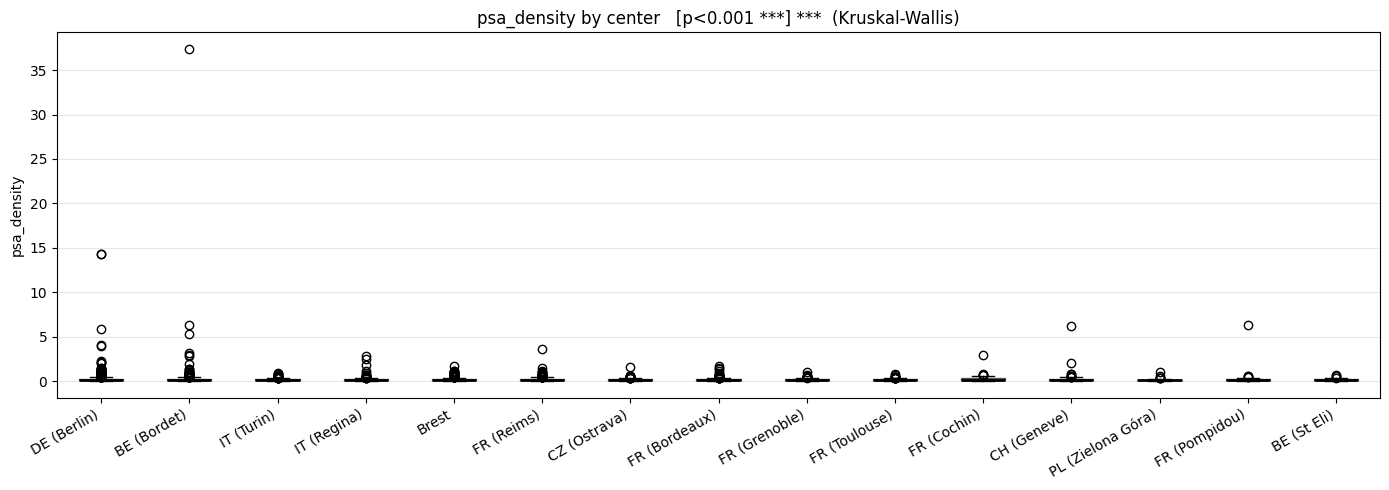

C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


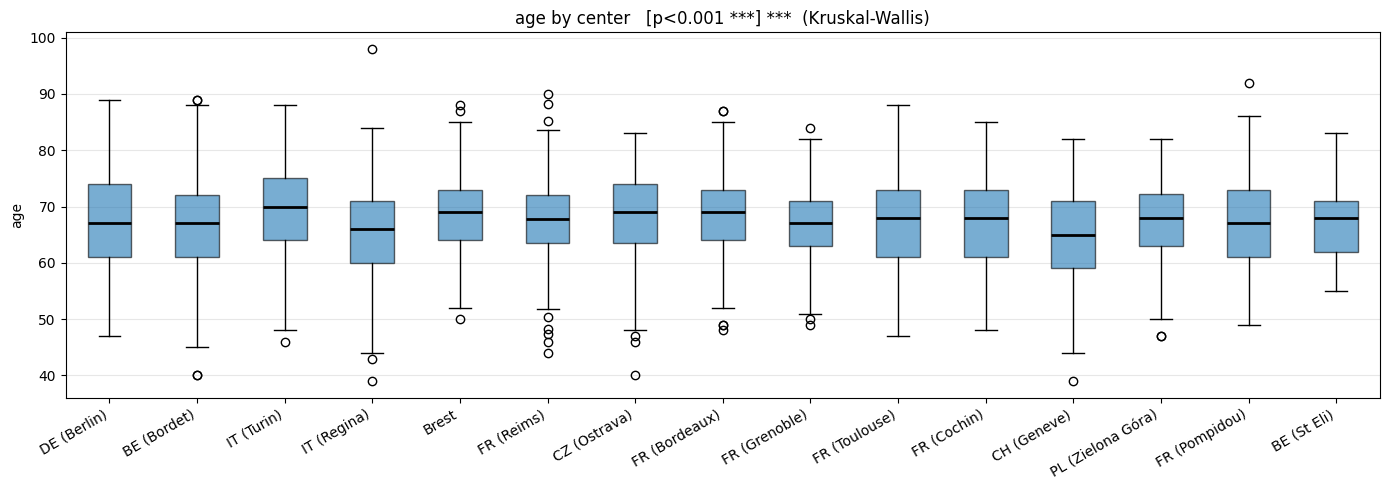

C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


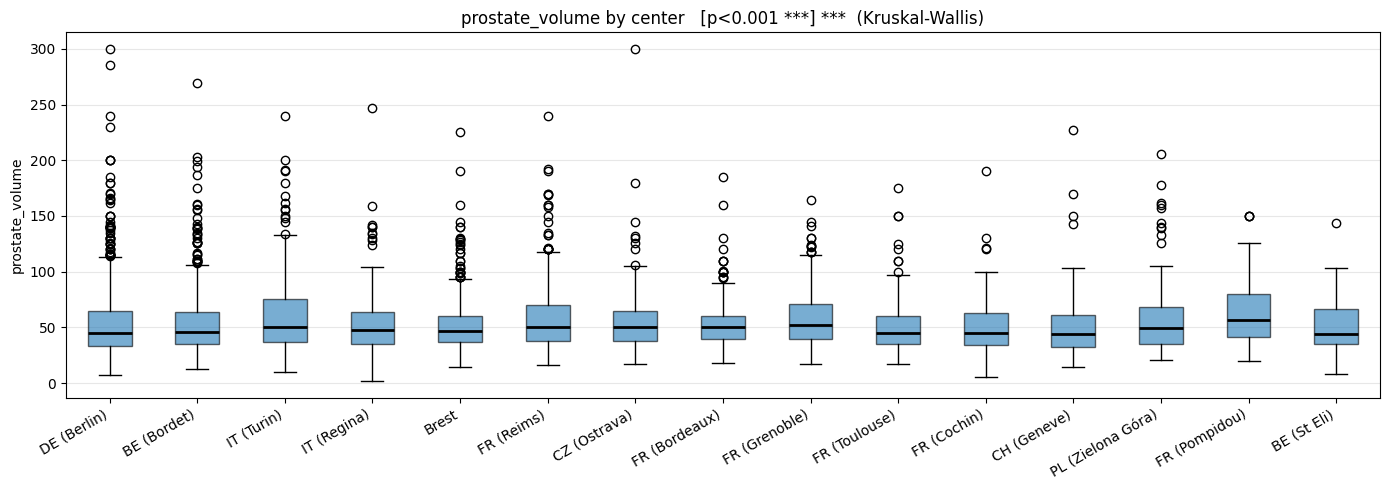

C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


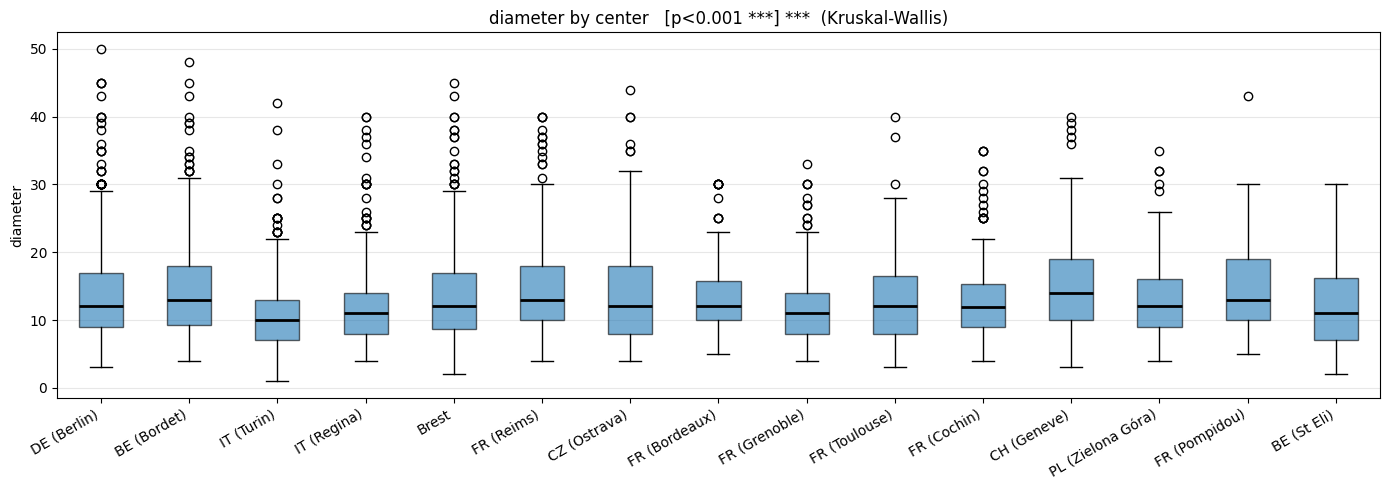

C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


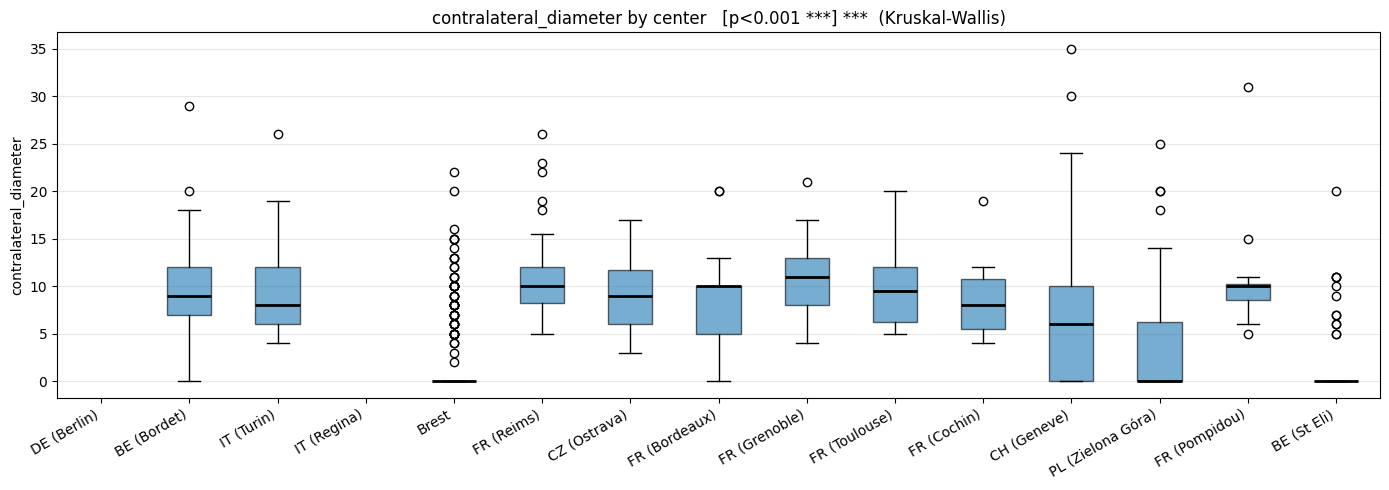

C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


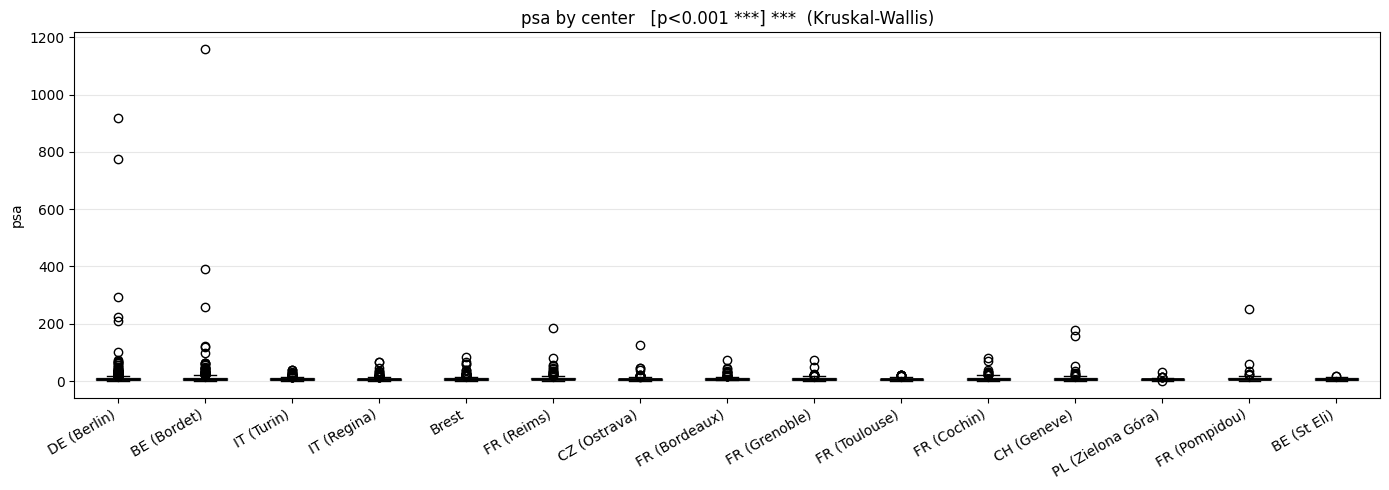

C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


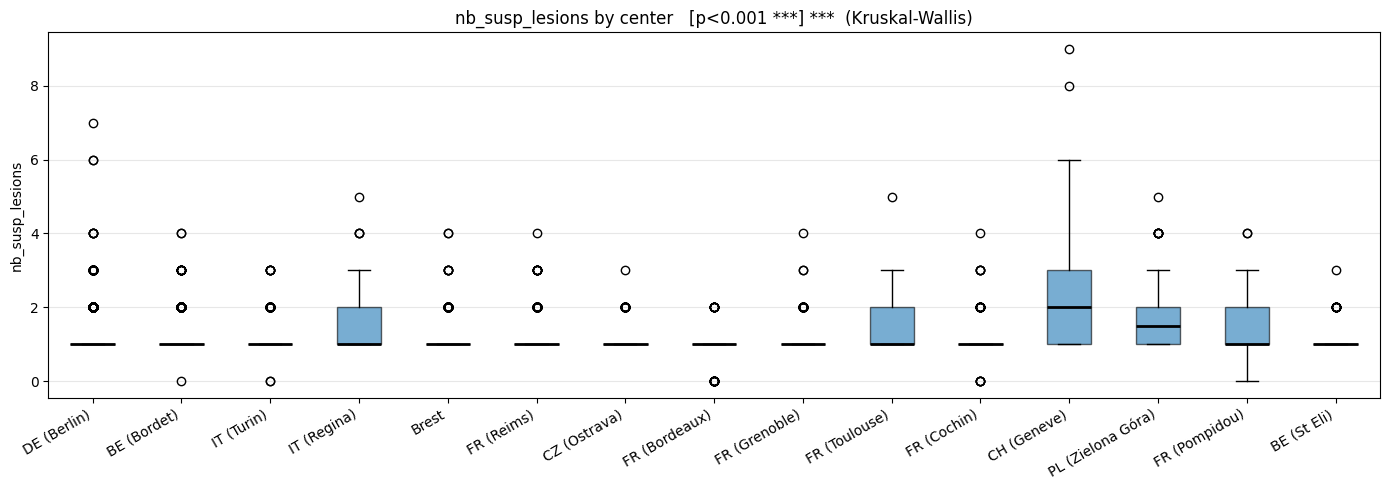

C:\Users\jonat\AppData\Local\Temp\ipykernel_28356\2925999777.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,


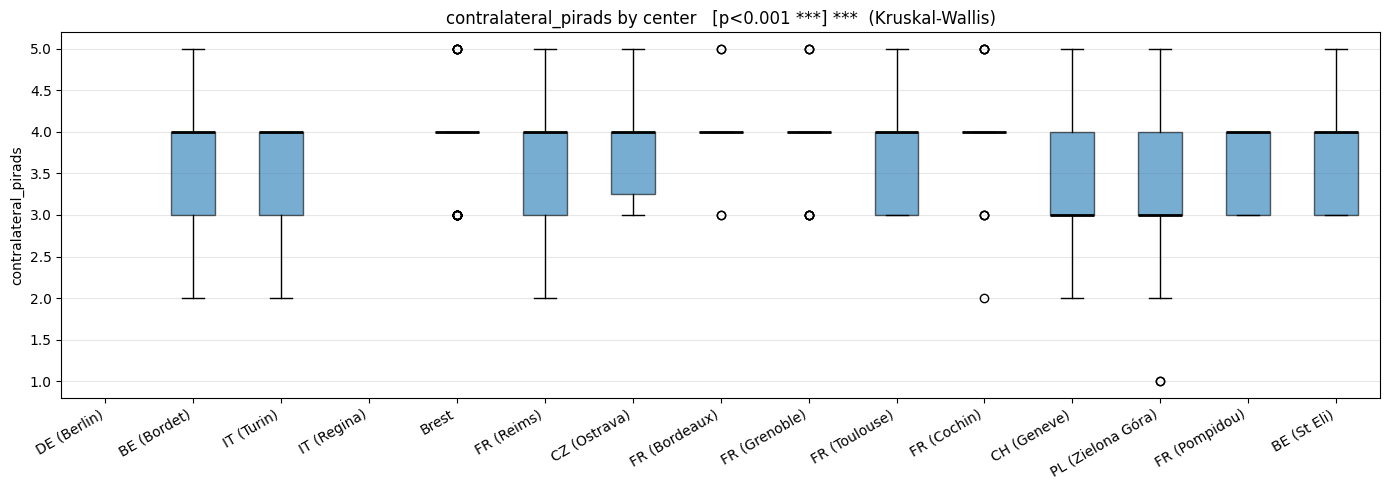

In [9]:
# Plot continuous features in SHAP order
continuous_shap = [f for f in SHAP_ORDER if f in CONTINUOUS_FEATURES]

for feat in continuous_shap:
    p = kruskal_pvalue(df, feat)
    flag = ' ***' if (not np.isnan(p) and p < 0.001) else (' *' if (not np.isnan(p) and p < 0.05) else '')

    fig, ax = plt.subplots(figsize=(14, 5))
    plot_data = [df.loc[df['Center'] == c, feat].dropna().values for c in CENTER_ORDER]
    bp = ax.boxplot(plot_data, labels=CENTER_ORDER, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor('#1f77b4')
        patch.set_alpha(0.6)
    ax.set_xticklabels(CENTER_ORDER, rotation=30, ha='right')
    ax.set_ylabel(feat)
    ax.set_title(f'{feat} by center   [{pval_label(p)}]{flag}  (Kruskal-Wallis)')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'fig_cont_{feat}.png', dpi=150)
    plt.show()

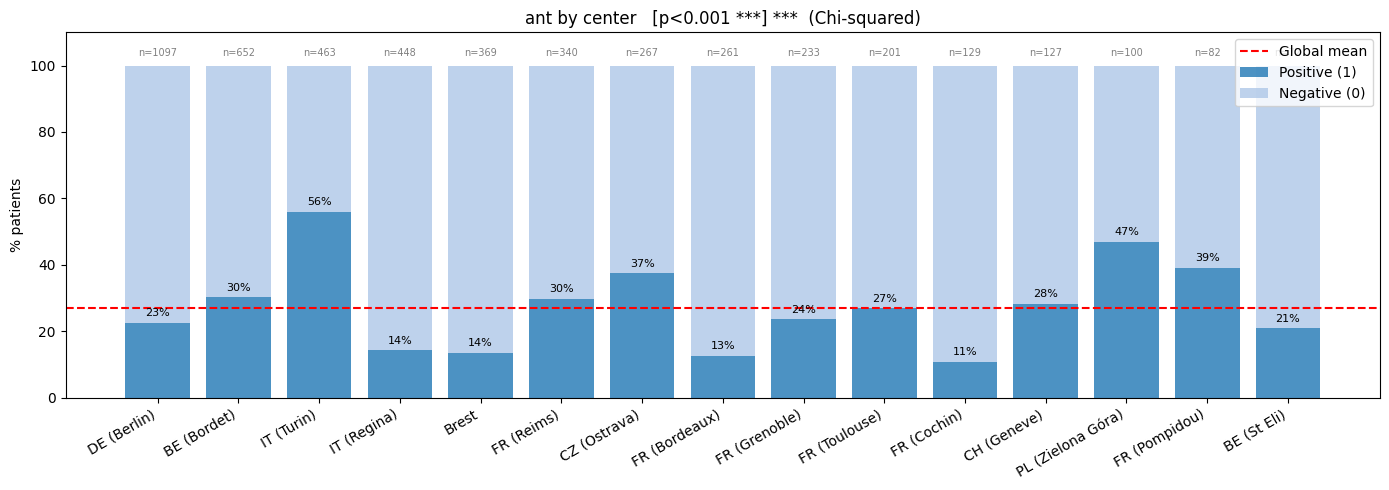

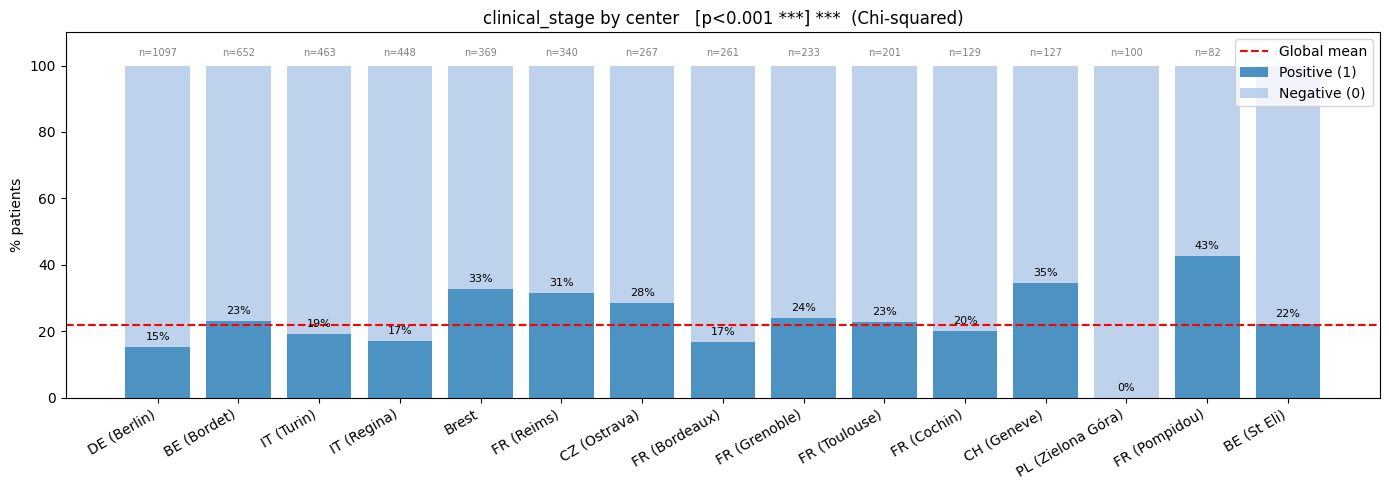

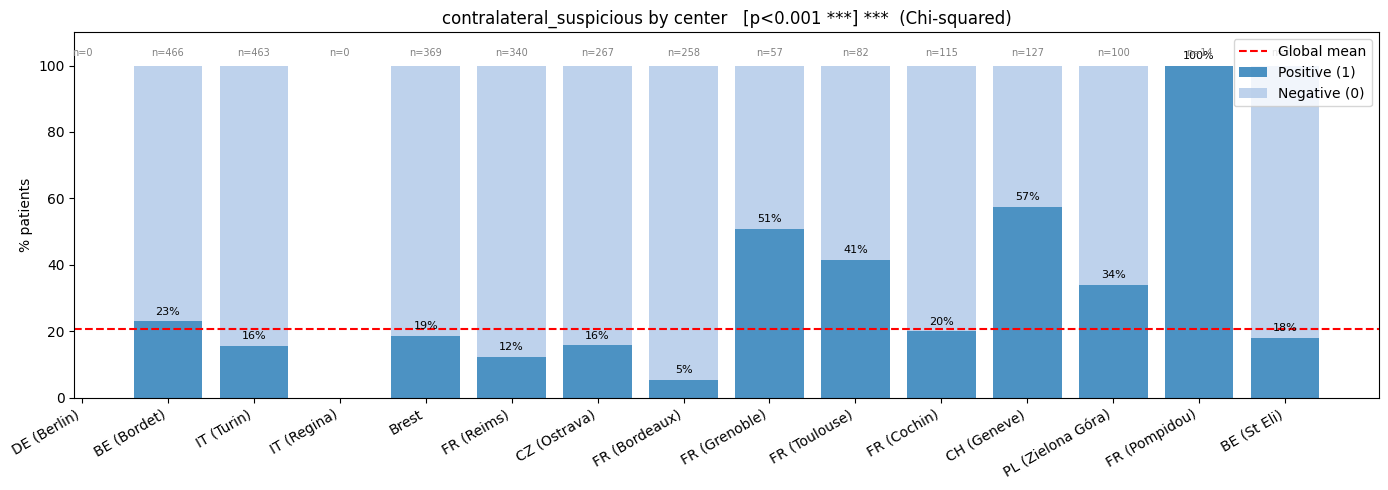

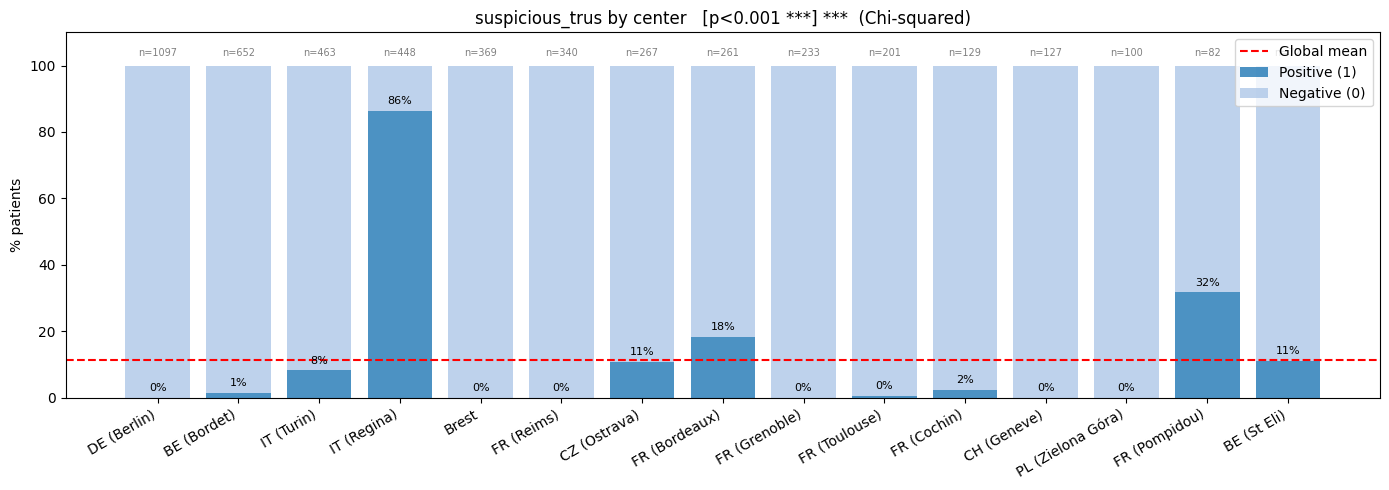

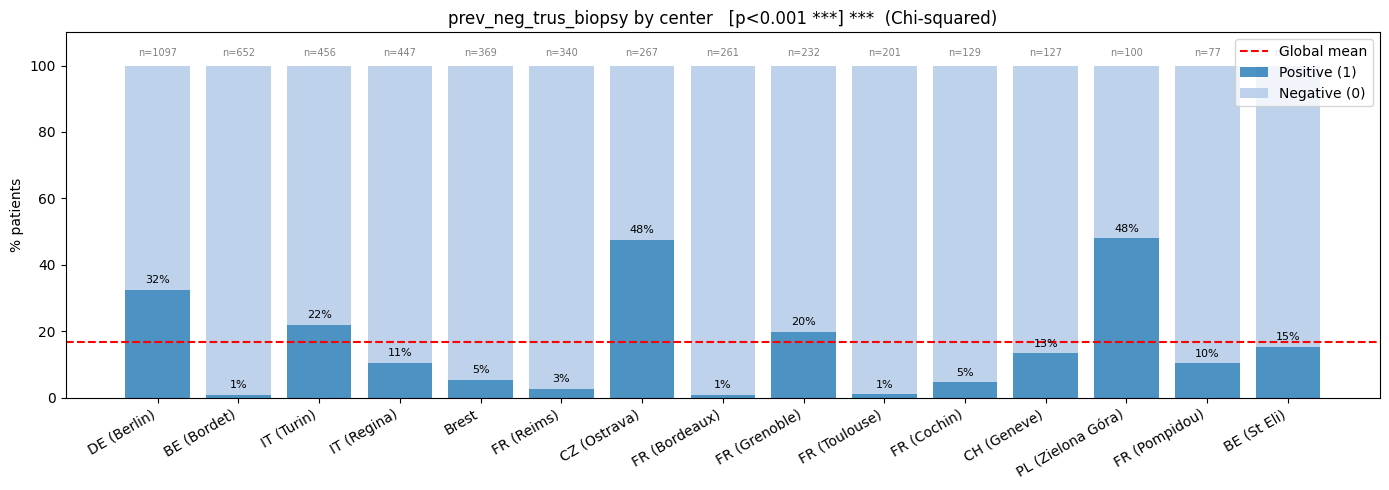

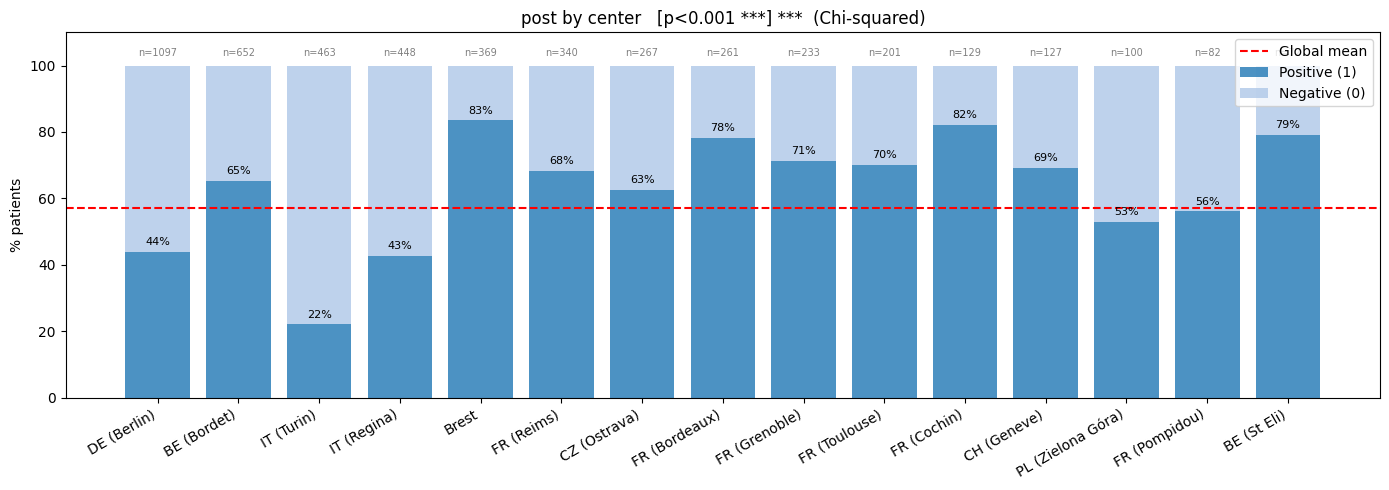

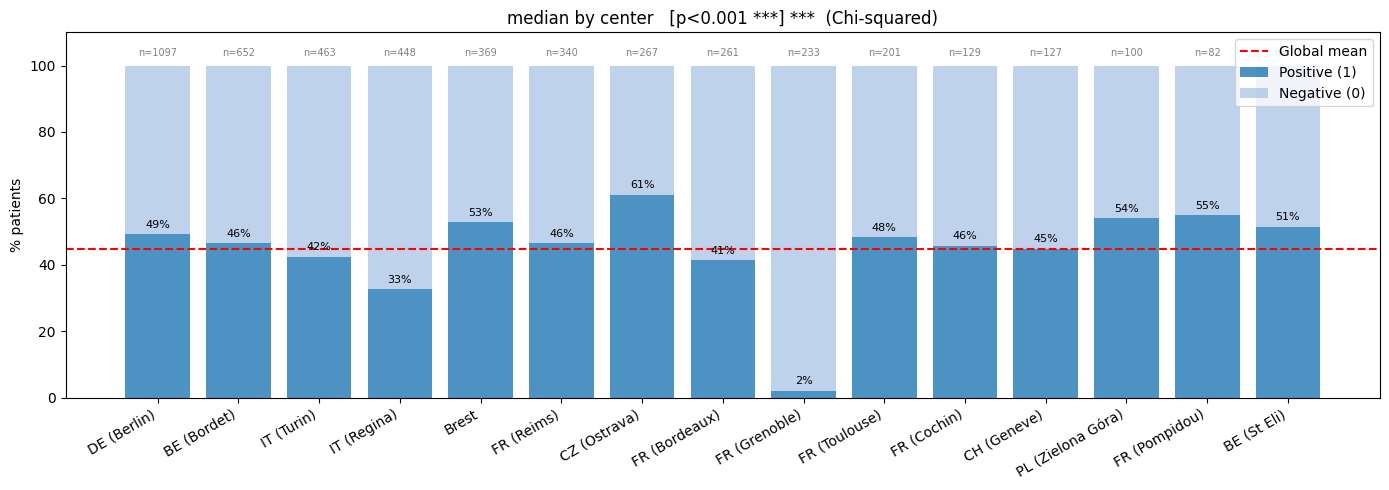

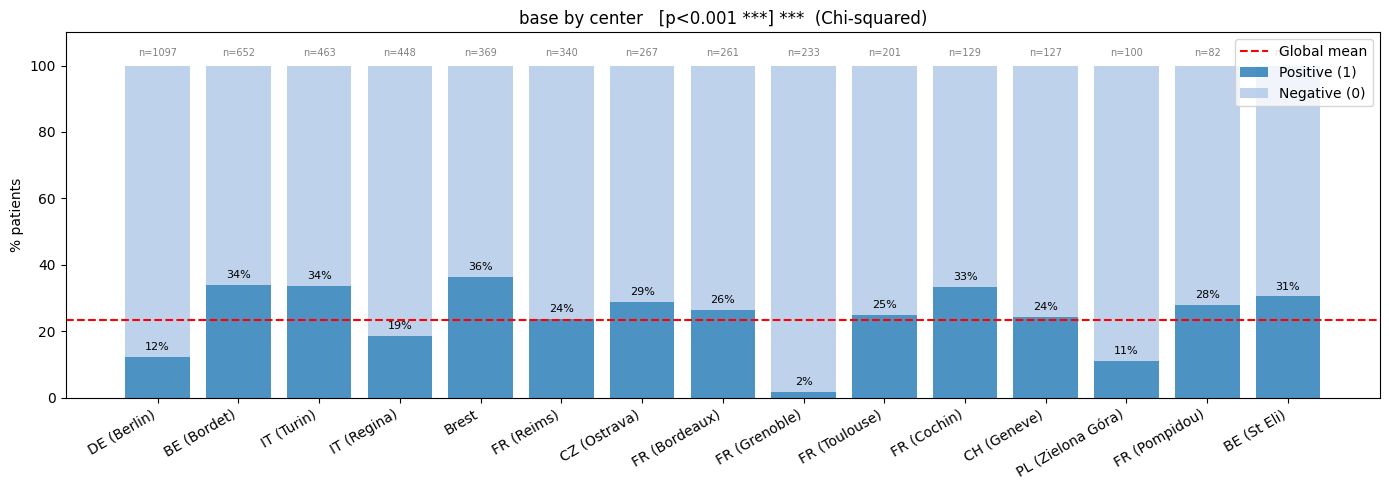

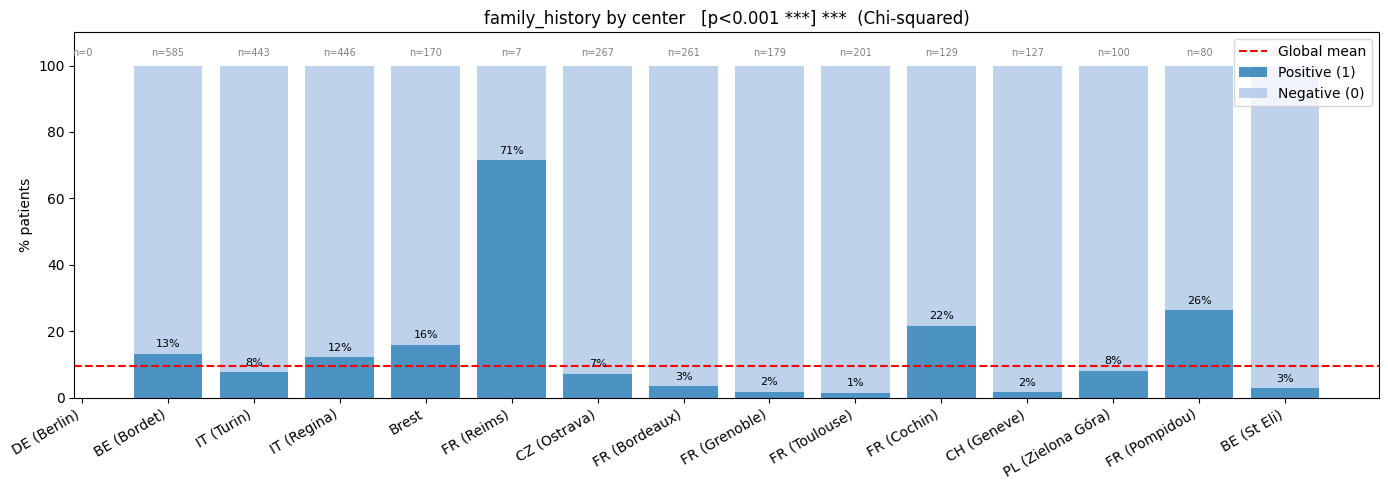

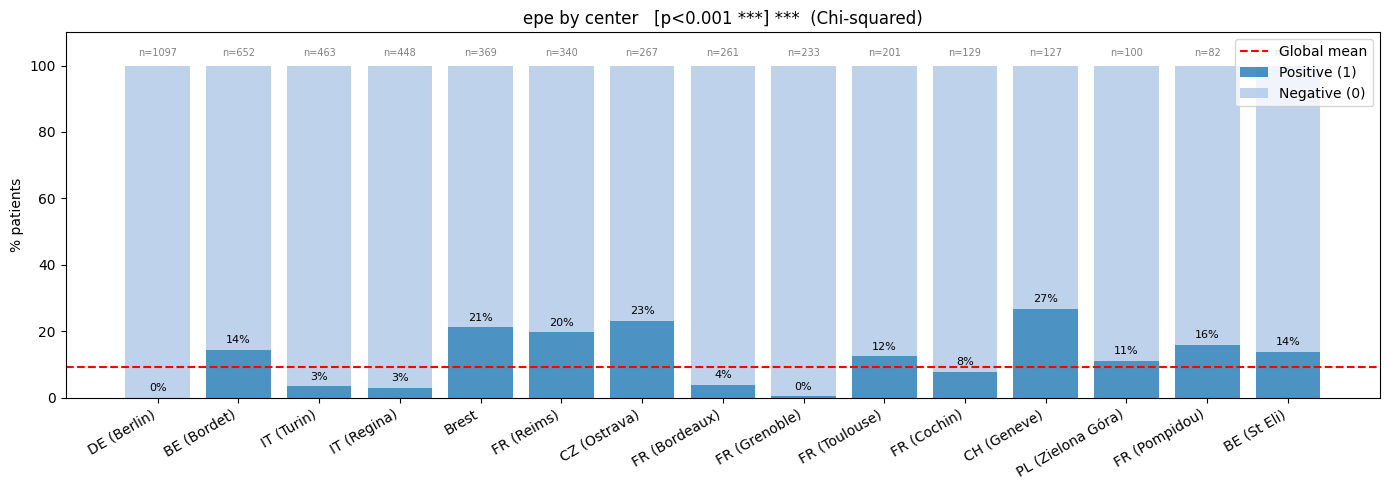

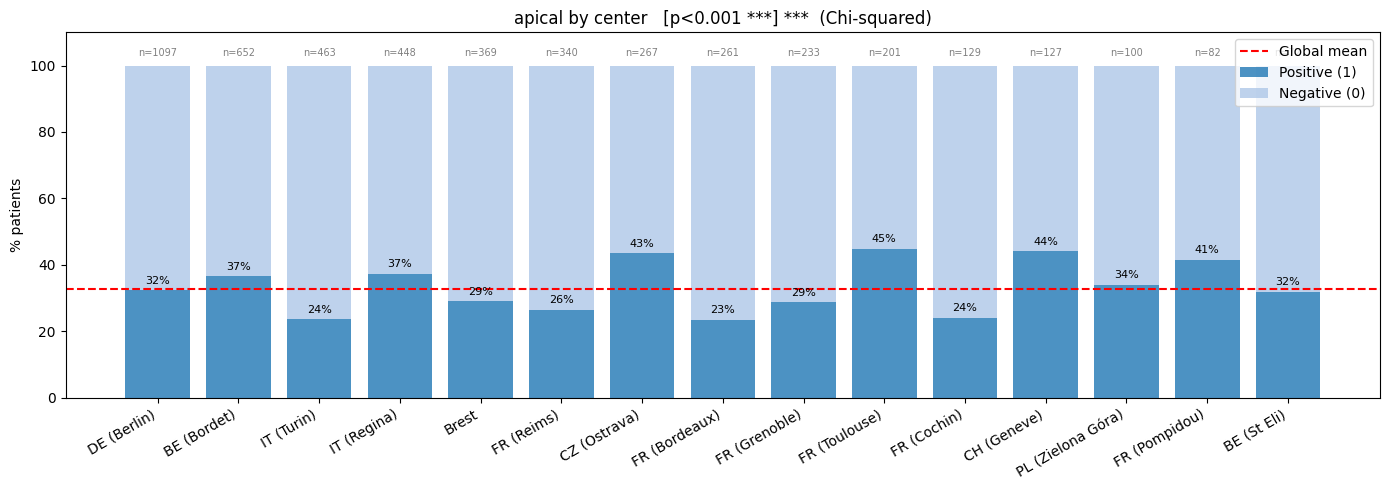

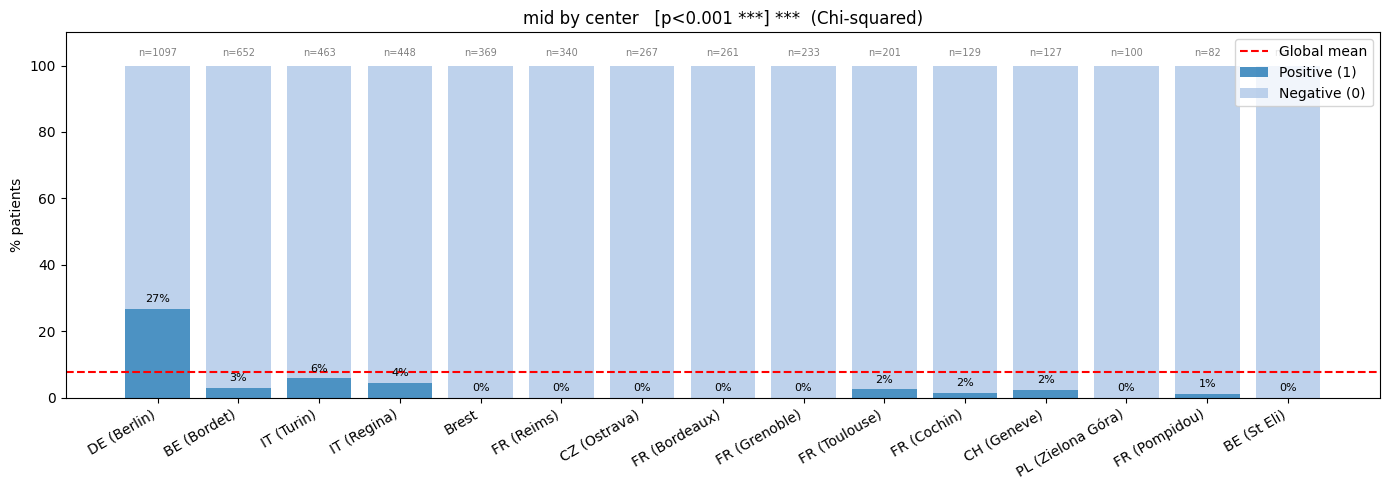

In [10]:
# Plot binary features in SHAP order
binary_shap = [f for f in SHAP_ORDER if f in BINARY_FEATURES]

for feat in binary_shap:
    p = chi2_pvalue(df, feat)
    flag = ' ***' if (not np.isnan(p) and p < 0.001) else (' *' if (not np.isnan(p) and p < 0.05) else '')

    # % positive per center
    pct_pos = df.groupby('Center')[feat].apply(lambda x: x.dropna().mean() * 100).reindex(CENTER_ORDER)
    pct_neg = 100 - pct_pos
    n_per_center = df.groupby('Center')[feat].apply(lambda x: x.notna().sum()).reindex(CENTER_ORDER)

    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(CENTER_ORDER))
    ax.bar(x, pct_pos, color='#1f77b4', alpha=0.8, label='Positive (1)')
    ax.bar(x, pct_neg, bottom=pct_pos, color='#aec7e8', alpha=0.8, label='Negative (0)')
    ax.set_xticks(list(x))
    ax.set_xticklabels(CENTER_ORDER, rotation=30, ha='right')
    ax.set_ylabel('% patients')
    ax.set_ylim(0, 110)
    ax.axhline(df[feat].dropna().mean() * 100, color='red', linestyle='--', linewidth=1.5, label='Global mean')
    for i, (pos, n) in enumerate(zip(pct_pos, n_per_center)):
        if not np.isnan(pos):
            ax.text(i, pos + 2, f'{pos:.0f}%', ha='center', fontsize=8)
        ax.text(i, 103, f'n={n}', ha='center', fontsize=7, color='gray')
    ax.set_title(f'{feat} by center   [{pval_label(p)}]{flag}  (Chi-squared)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'fig_bin_{feat}.png', dpi=150)
    plt.show()

---
## 5. Summary: Statistical Test Results by Feature

In [11]:
summary_rows = []
for feat in SHAP_ORDER:
    if feat in CONTINUOUS_FEATURES:
        p = kruskal_pvalue(df, feat)
        test = 'Kruskal-Wallis'
        ftype = 'continuous'
    else:
        p = chi2_pvalue(df, feat)
        test = 'Chi-squared'
        ftype = 'binary'
    shap_rank = SHAP_ORDER.index(feat) + 1
    sig = '***' if (not np.isnan(p) and p < 0.001) else ('**' if (not np.isnan(p) and p < 0.01) else ('*' if (not np.isnan(p) and p < 0.05) else ''))
    summary_rows.append({'shap_rank': shap_rank, 'feature': feat, 'type': ftype, 'test': test,
                          'p_value': round(p, 5) if not np.isnan(p) else np.nan, 'significance': sig})

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

# Highlight significant ones
print('\n--- Features with significant center differences (p < 0.05) ---')
sig_feats = summary[summary['significance'] != '']
print(sig_feats[['shap_rank','feature','type','p_value','significance']].to_string(index=False))

 shap_rank                  feature       type           test  p_value significance
         1                   pirads continuous Kruskal-Wallis  0.00000          ***
         2              psa_density continuous Kruskal-Wallis  0.00000          ***
         3                      age continuous Kruskal-Wallis  0.00000          ***
         4          prostate_volume continuous Kruskal-Wallis  0.00000          ***
         5                      ant     binary    Chi-squared  0.00000          ***
         6           clinical_stage     binary    Chi-squared  0.00000          ***
         7                 diameter continuous Kruskal-Wallis  0.00000          ***
         8 contralateral_suspicious     binary    Chi-squared  0.00000          ***
         9   contralateral_diameter continuous Kruskal-Wallis  0.00000          ***
        10          suspicious_trus     binary    Chi-squared  0.00000          ***
        11                      psa continuous Kruskal-Wallis  0.00000      

---
## 6. Heatmap: median / % positive per feature per center (continuous features only)

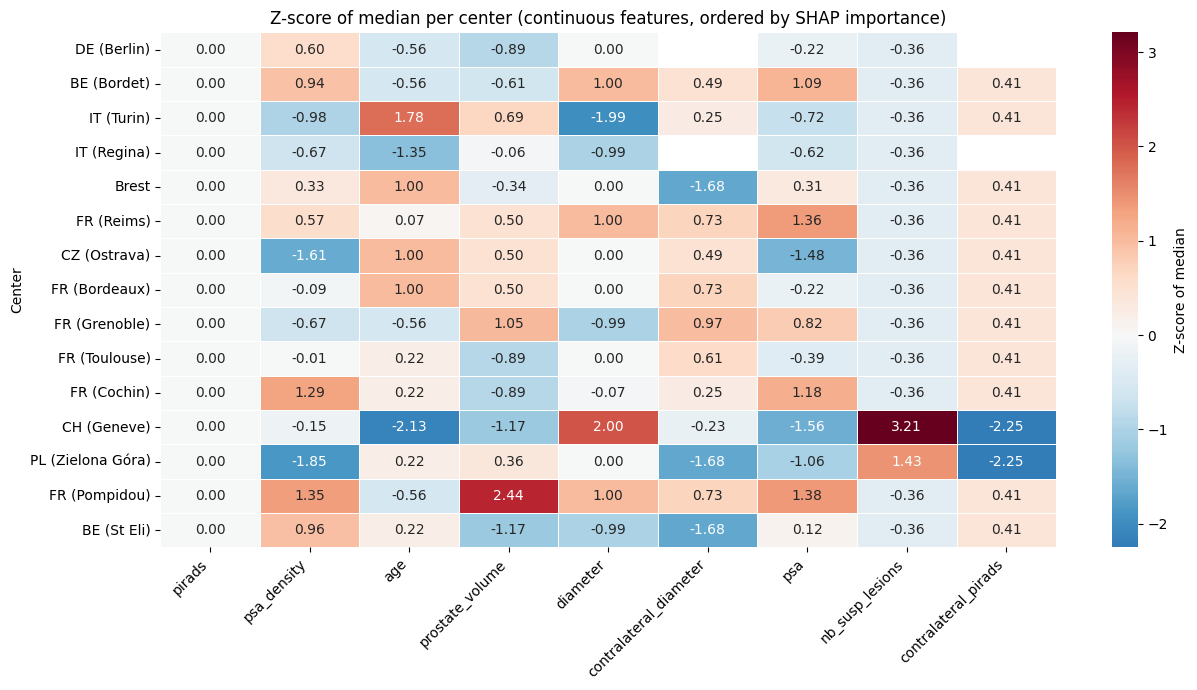

In [12]:
# Z-score of medians across centers for each continuous feature
median_by_center = df.groupby('Center')[CONTINUOUS_FEATURES].median().reindex(CENTER_ORDER)

# Z-score per feature to make them comparable
median_z = (median_by_center - median_by_center.mean()) / (median_by_center.std() + 1e-9)
# Order columns by SHAP rank
col_order = [f for f in SHAP_ORDER if f in CONTINUOUS_FEATURES]
median_z = median_z[col_order]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(median_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Z-score of median'})
ax.set_title('Z-score of median per center (continuous features, ordered by SHAP importance)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig6_median_zscore_heatmap.png', dpi=150)
plt.show()

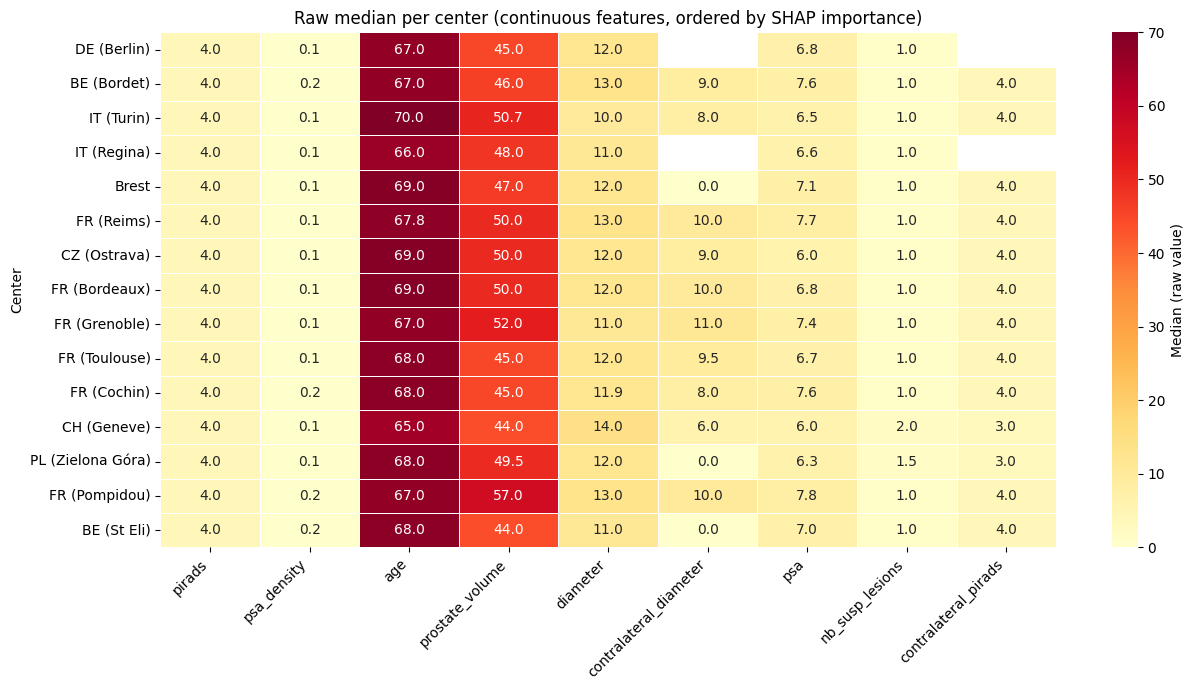

In [13]:
# Raw median values per center (same layout as z-score heatmap)
col_order = [f for f in SHAP_ORDER if f in CONTINUOUS_FEATURES]
median_raw = df.groupby('Center')[CONTINUOUS_FEATURES].median().reindex(CENTER_ORDER)[col_order]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(median_raw, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Median (raw value)'})
ax.set_title('Raw median per center (continuous features, ordered by SHAP importance)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig7_median_raw_heatmap.png', dpi=150)
plt.show()